In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/distance_from_centre.csv')
df1['condition'] = 'wiii8'


df2 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/distance_from_centre.csv')
df2['condition'] = 'anosmic'


df3 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/distance_from_centre.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/distance_from_centre.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm-1/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/distance_from_centre.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_65358/553538025.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group, x='condition', y='distance_from_centre', errorbar='sd', palette='Set2')


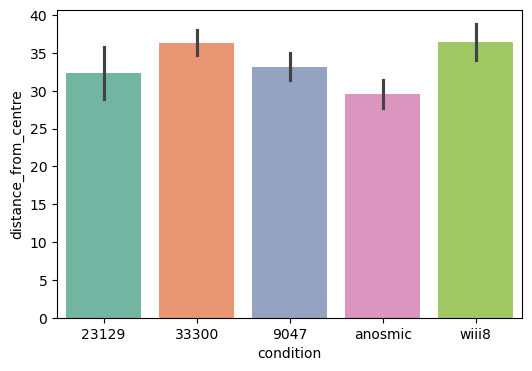

In [2]:

group = df.groupby(['condition', 'file'])['distance_from_centre'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=group, x='condition', y='distance_from_centre', errorbar='sd', palette='Set2')
plt.show()



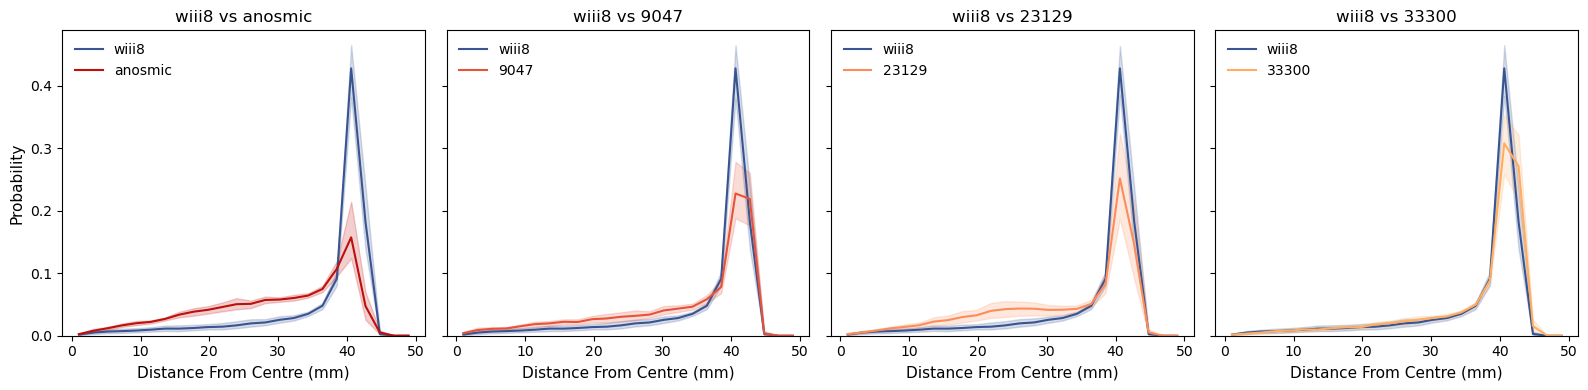

In [3]:
bins = np.linspace(0, 50, 25)  # 0 to 2.5 in 0.1 increments
df['distance_bin'] = pd.cut(df['distance_from_centre'], bins, include_lowest=True)
df['bin_center'] = df['distance_bin'].apply(lambda x: x.mid if pd.notna(x) else np.nan)


counts = (
    df.groupby(['file', 'condition', 'bin_center'])
    .size()
    .groupby(['file', 'condition'], group_keys=False)
    .apply(lambda x: x / x.sum())
    .reset_index(name='density')
)


condition_colors = {
    'wiii8': '#385491',
    'anosmic': '#be0f0a',
    '9047': '#e7533a',
    '23129': '#fc8c59',
    '33300': '#fead61',
}

mutants = ['anosmic', '9047', '23129', '33300']
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)

for ax, mutant in zip(axes, mutants):
    comparison = counts[counts['condition'].isin(['wiii8', mutant])]

    sns.lineplot(
        data=comparison,
        x='bin_center',
        y='density',
        hue='condition',
        hue_order=['wiii8', mutant],
        palette=condition_colors,
        errorbar=('ci', 95),
        ax=ax,
    )

    ax.set_title(f'wiii8 vs {mutant}', fontsize=12)
    ax.set_xlabel('Distance From Centre (mm)', fontsize=11)
    ax.set_ylabel('Probability' if ax is axes[0] else '', fontsize=11)
    ax.set_ylim(bottom=0)
    ax.legend(title=None, frameon=False)

plt.tight_layout()
plt.show()